In [ ]:
# ===============================================================
# Imports + CPU-only setup + JAX CFD solver
# ===============================================================

from functools import partial
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU

import jax
import jax.numpy as jnp
from jax import lax

import numpy as onp
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from numpyro.infer.initialization import init_to_value

# CPU only for Jax
device_torch = torch.device("cpu")
print("Torch using device:", device_torch)

jax.config.update("jax_platform_name", "cpu")
print("JAX devices:", jax.devices())

Torch using device: cpu
JAX devices: [CpuDevice(id=0)]


In [ ]:
# ==============================================================
# Forward Solver (JAX CFD)
# ==============================================================
# This block defines the forward quasi-1D compressible flow solver
# using JAX. It includes helper functions for:
#   1. grid spacing
#   2. energy and state conversions
#   3. pressure computation
#   4. flux splitting
#   5. time-step evaluation
#   6. boundary condition application
#   7. upwind finite-volume update
#   8. full forward simulation for Mach prediction
# ==============================================================

def DeltaCal_jnp(x):
    dx = jnp.zeros_like(x)
    dx = dx.at[:-1].set(x[1:] - x[:-1])
    dx = dx.at[-1].set(dx[-2])
    return dx


def EnergyCal_jnp(rho, u, P, gamma):
    return P / (gamma - 1.0) + 0.5 * rho * u**2


def ConservCal_jnp(rho, u, E, A):
    Q0 = rho * A
    Q1 = rho * u * A
    Q2 = E * A
    return jnp.stack([Q0, Q1, Q2], axis=0)


def PrimCal_jnp(Q, A):
    rho = Q[0] / A
    u = Q[1] / Q[0]
    E = Q[2] / A
    return rho, u, E


def PressureCal_jnp(rho, u, E, gamma):
    return (gamma - 1.0) * (E - 0.5 * rho * u**2)


def FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma):
    N = u.size
    zeros = jnp.zeros(N)

    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c

    # Flow regime masks
    mask_sub = jnp.abs(M) < 1.0
    mask_le_neg1 = M <= -1.0
    mask_gt_pos1 = M > 1.0

    # Pressure splitting terms
    PP = jnp.where(mask_sub, 0.5 * (1.0 + M) * P, 0.0)
    PN = jnp.where(mask_sub, 0.5 * (1.0 - M) * P, 0.0)
    PuP = jnp.where(mask_sub, 0.5 * (u + c) * P, 0.0)
    PuN = jnp.where(mask_sub, 0.5 * (u - c) * P, 0.0)

    PP = jnp.where(mask_gt_pos1, P, PP)
    PuP = jnp.where(mask_gt_pos1, u * P, PuP)
    PN = jnp.where(mask_le_neg1, P, PN)
    PuN = jnp.where(mask_le_neg1, u * P, PuN)

    # Positive flux
    Fp0 = jnp.where(u > 0.0, rho * u * A, 0.0)
    Fp1 = jnp.where(u > 0.0, (rho * u**2 + PP) * A, PP * A)
    Fp2 = jnp.where(u > 0.0, (u * E + PuP) * A, PuP * A)

    # Negative flux
    Fn0 = jnp.where(u < 0.0, rho * u * A, 0.0)
    Fn1 = jnp.where(u < 0.0, (rho * u**2 + PN) * A, PN * A)
    Fn2 = jnp.where(u < 0.0, (u * E + PuN) * A, PuN * A)

    FP = jnp.stack([Fp0, Fp1, Fp2], axis=0)
    FN = jnp.stack([Fn0, Fn1, Fn2], axis=0)

    # Source term from variable area nozzle
    H = jnp.stack([zeros, P * dAdx, zeros], axis=0)

    return FP, FN, H


def TimeStep_jnp(dx, rho, u, P, cfl, gamma):
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    cmax = jnp.max(jnp.abs(u) + c)
    return cfl * dx[1] / cmax


@partial(jax.jit, static_argnames=("gamma",))
def apply_bc(rho, u, P, E, gamma):
    # Inlet boundary condition (supersonic)
    rho = rho.at[0].set(0.5008261)
    u = u.at[0].set(1.0991840)
    P = P.at[0].set(0.2712900)
    E = E.at[0].set(EnergyCal_jnp(rho[0], u[0], P[0], gamma))

    # Outlet boundary condition (subsonic)
    rho = rho.at[-1].set(2.0 * rho[-2] - rho[-3])
    u = u.at[-1].set(2.0 * u[-2] - u[-3])
    P = P.at[-1].set(0.5156000)
    E = E.at[-1].set(EnergyCal_jnp(rho[-1], u[-1], P[-1], gamma))

    return rho, u, P, E


def upwind_update_vec_jnp(Q, A, dAdx, dx, gamma, dt):
    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)

    # Apply boundary conditions in primitive form
    rho, u, P, E = apply_bc(rho, u, P, E, gamma)

    # Rebuild conservative state after BC enforcement
    Q = ConservCal_jnp(rho, u, E, A)

    # Compute fluxes and source term
    FP, FN, H = FluxSplitCal_vec_jnp(rho, u, P, E, A, dAdx, gamma)

    def update_col(i, Q_state):
        Qi = Q_state[:, i]
        dF = FP[:, i] - FP[:, i - 1] + FN[:, i + 1] - FN[:, i]
        Qi_new = Qi - (dt / dx[i]) * dF + dt * H[:, i]
        return Q_state.at[:, i].set(Qi_new)

    N = A.size
    Q_new = lax.fori_loop(1, N - 1, update_col, Q)
    return Q_new


@partial(jax.jit, static_argnames=("n_steps", "gamma", "cfl"))
def forward_only_jax(x, A, n_steps=5000, gamma=1.4, cfl=0.9):
    x = jnp.asarray(x)
    A = jnp.asarray(A)
    N = A.size

    # Compute dA/dx using one-sided differences at boundaries
    # and centered differences in the interior
    dAdx0 = (A[1] - A[0]) / (x[1] - x[0])
    dAdxN1 = (A[-1] - A[-2]) / (x[-1] - x[-2])
    dAdx_mid = (A[2:] - A[:-2]) / (x[2:] - x[:-2])
    dAdx = jnp.concatenate([dAdx0[None], dAdx_mid, dAdxN1[None]])

    dx = DeltaCal_jnp(x)

    # Initial condition
    rho = jnp.ones(N) * 0.7511383
    u = jnp.ones(N) * 0.4416178
    P = jnp.ones(N) * 0.2156000
    E = EnergyCal_jnp(rho, u, P, gamma)
    Q = ConservCal_jnp(rho, u, E, A)

    def body_fun(step, Q_state):
        rho0, u0, E0 = PrimCal_jnp(Q_state, A)
        P0 = PressureCal_jnp(rho0, u0, E0, gamma)
        dt = TimeStep_jnp(dx, rho0, u0, P0, cfl, gamma)
        return upwind_update_vec_jnp(Q_state, A, dAdx, dx, gamma, dt)

    # March to steady solution
    Q = lax.fori_loop(0, n_steps, body_fun, Q)

    # Recover final primitive variables
    rho, u, E = PrimCal_jnp(Q, A)
    P = PressureCal_jnp(rho, u, E, gamma)

    # Compute Mach number
    c = jnp.sqrt(jnp.abs(gamma * P / rho))
    M = u / c

    return rho, u, P, M

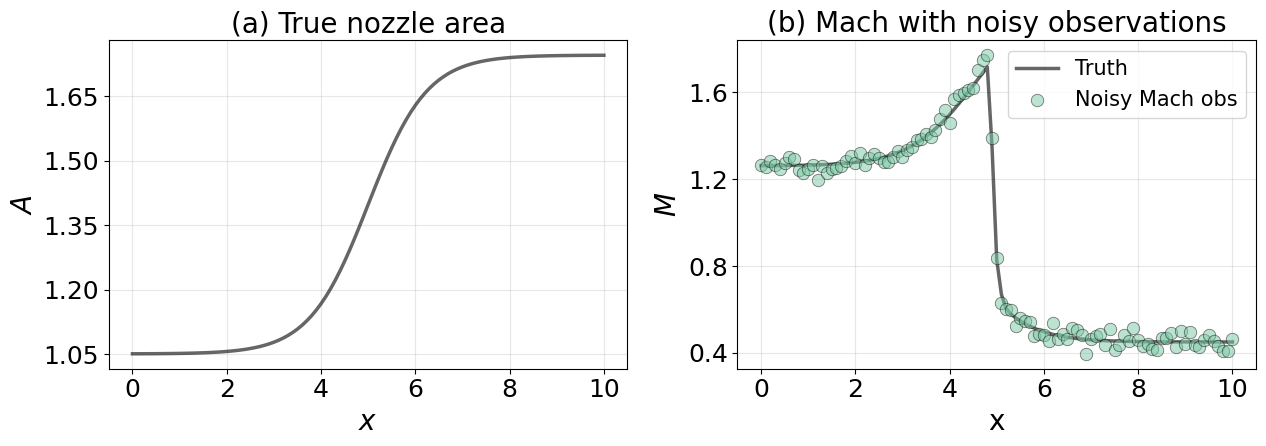

In [4]:
# ===================================
# Figure: True nozzle + noisy Mach data
# (a) True nozzle area, (b) Mach with noisy observations
# ===================================

from matplotlib.ticker import MaxNLocator

# -----------------------------
# 1) Reference nozzle geometry
# -----------------------------
def A_true_fn(x):
    return 1.398 + 0.347 * jnp.tanh(0.8 * x - 4.0)

N = 101
x = jnp.linspace(0.0, 10.0, N, dtype=jnp.float32)
L = float(x[-1])

A_true = A_true_fn(x)
A0_val  = float(A_true[0])
A10_val = float(A_true[-1])
dA0_val, dA10_val = 0.0, 0.0

# -----------------------------
# 2) Forward solve
# -----------------------------
_, _, _, M_true = forward_only_jax(x, A_true)

# -----------------------------
# 3) Noisy observations
# -----------------------------
rng = onp.random.default_rng(0)
noise_sigma = 0.03
M_obs = onp.array(M_true) + noise_sigma * rng.standard_normal((N,))
obs_idx = onp.arange(N, dtype=onp.int32)

# -----------------------------
# 4) High quality figure
# -----------------------------
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 15,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "lines.linewidth": 2.5,
})

x_np = onp.array(x)
A_true_np = onp.array(A_true)
M_true_np = onp.array(M_true)

fig = plt.figure(figsize=(13, 4.8))

# -------- Panel (a): Geometry --------
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(x_np, A_true_np, 'k-',lw=2.5, alpha = 0.6)
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$A$")
ax1.set_title("(a) True nozzle area")
ax1.grid(alpha=0.3)

# -------- Panel (b): Mach + noisy obs --------
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x_np, M_true_np, 'k-',lw=2.5, alpha = 0.6 ,label="Truth")

ax2.scatter(
    x_np,
    M_obs,
    s=80,
    facecolor="#7BC8A4",   
    edgecolor="black",
    linewidth=0.6,
    alpha=0.5,
    label="Noisy Mach obs",
    zorder=5
)



ax2.set_xlabel(r"x")
ax2.set_ylabel(r"$M$")
ax2.set_title("(b) Mach with noisy observations")
ax2.legend(frameon=True)
ax2.grid(alpha=0.3)
n_yticks = 6
ax1.yaxis.set_major_locator(MaxNLocator(nbins=n_yticks))
ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))

fig.tight_layout()

# -----------------------------
# Save for paper
# -----------------------------
# fig.savefig("R1.png", dpi=100, bbox_inches="tight")
plt.show()


# Increasing observation density for Mach number

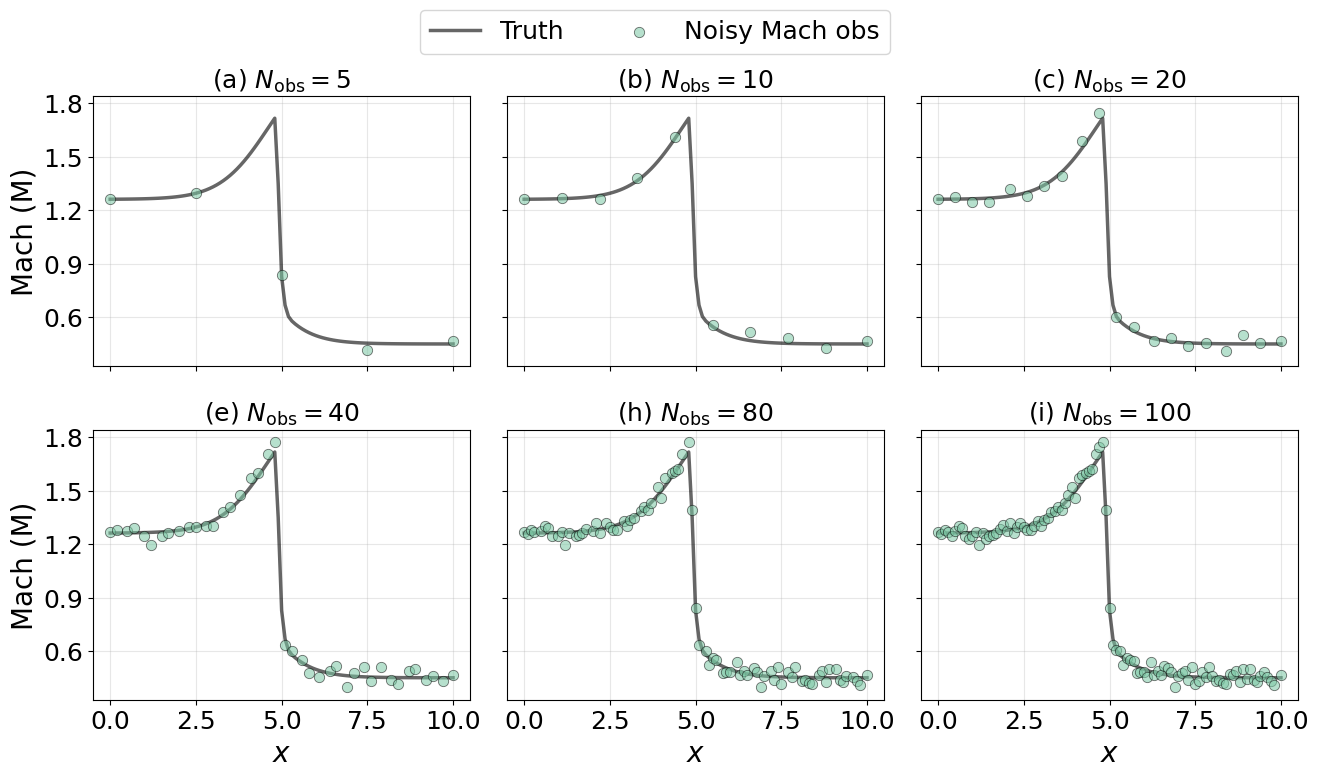

In [5]:
# ===================================
# Figure: Nine observation cases
# ===================================

import numpy as onp
import matplotlib.pyplot as plt
import jax.numpy as jnp
from matplotlib.ticker import MaxNLocator

# -----------------------------
# 1) Reference nozzle geometry
# -----------------------------
def A_true_fn(x):
    return 1.398 + 0.347 * jnp.tanh(0.8 * x - 4.0)

N = 101
x = jnp.linspace(0.0, 10.0, N, dtype=jnp.float32)
L = float(x[-1])

A_true = A_true_fn(x)

# -----------------------------
# 2) Forward solve
# -----------------------------
_, _, _, M_true = forward_only_jax(x, A_true)

# -----------------------------
# 3) Observation indices helper
# -----------------------------
def obs_indices(N, Nobs):
    if Nobs >= N:
        return onp.arange(N, dtype=onp.int32)
    return onp.linspace(0, N - 1, Nobs, dtype=onp.int32)

# -----------------------------
# 4) Noise addition
# -----------------------------
rng = onp.random.default_rng(0)
noise_sigma = 0.03

x_np      = onp.asarray(x)
M_true_np = onp.asarray(M_true)
M_obs_all = M_true_np + noise_sigma * rng.standard_normal((N,))

# -----------------------------
# 5) Style
# -----------------------------
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "lines.linewidth": 2.5,
})

# -----------------------------
# 6) Plot 3×3 panels
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8), sharex=True, sharey=True)

cases = [
    (5,   "(a) $N_{\\mathrm{obs}}=5$"),
    (10,  "(b) $N_{\\mathrm{obs}}=10$"),
    (20,  "(c) $N_{\\mathrm{obs}}=20$"),
    (40,  "(e) $N_{\\mathrm{obs}}=40$"),
    (80,  "(h) $N_{\\mathrm{obs}}=80$"),
    (100, "(i) $N_{\\mathrm{obs}}=100$"),
]

for ax, (Nobs, title) in zip(axes.ravel(), cases):
    idx = obs_indices(N, Nobs)

    # True Mach
    ax.plot(x_np, M_true_np, "k-", lw=2.5, alpha=0.6, label="Truth")

    # Noisy observations
    ax.scatter(
        x_np[idx], M_obs_all[idx],
        s=55,
        facecolor="#7BC8A4",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.55,
        label="Noisy Mach obs",
        zorder=5
    )

    ax.set_title(title)
    ax.grid(alpha=0.30)

# axis labels 
for ax in axes[:, 0]:
    ax.set_ylabel(r"Mach (M)")
for ax in axes[-1, :]:
    ax.set_xlabel(r"$x$")

n_yticks = 6
for ax in axes.ravel():
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_yticks))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1)
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

# -----------------------------
# 7) Save
# -----------------------------
# fig.savefig("fig_R1_observation_cases_3x3.png", dpi=300, bbox_inches="tight")

plt.show()


# 1. Grometry Parameterization: Discrete Model

In [ ]:
# ===============================================================
# Prior bounds + initial condition plot (Discrete PL A(x))
# ===============================================================

def make_x_ctrl(x_full, n_ctrl_each=10):
    x_full_np = onp.asarray(x_full, dtype=onp.float32)
    x_min, x_max = float(x_full_np[0]), float(x_full_np[-1])
    x_mid = 0.5 * (x_min + x_max)
    left  = onp.linspace(x_min, x_mid, n_ctrl_each, endpoint=False, dtype=onp.float32)
    right = onp.linspace(x_mid, x_max, n_ctrl_each, endpoint=True,  dtype=onp.float32)
    return onp.concatenate([left, right])

def make_interp_matrix(x_full, x_ctrl):
    x_full = onp.asarray(x_full, dtype=onp.float32)
    x_ctrl = onp.asarray(x_ctrl, dtype=onp.float32)
    N, K = x_full.shape[0], x_ctrl.shape[0]
    Phi = onp.zeros((N, K), dtype=onp.float32)

    j = onp.searchsorted(x_ctrl, x_full, side="right") - 1
    j = onp.clip(j, 0, K-2)

    x0 = x_ctrl[j]; x1 = x_ctrl[j+1]
    w1 = (x_full - x0) / onp.maximum(x1 - x0, 1e-6)
    w0 = 1.0 - w1

    Phi[onp.arange(N), j]     = w0
    Phi[onp.arange(N), j + 1] = w1

    mask_last = (x_full >= x_ctrl[-1])
    Phi[mask_last, :] = 0.0
    Phi[mask_last, -1] = 1.0
    return Phi

# Control points + interpolation matrix
K_disc = 20
x_ctrl_disc_np = make_x_ctrl(x, n_ctrl_each=K_disc//2)
Phi_disc_np    = make_interp_matrix(x, x_ctrl_disc_np)

# Baseline initial guess (straight line between endpoints)
A0_full_disc = onp.linspace(A0_val, A10_val, N).astype(onp.float32)
A0_ctrl_disc = onp.interp(x_ctrl_disc_np, x_np, A0_full_disc)

# Prior bounds around baseline control points (here ±20% like your later section)
lower_ctrl = 0.7 * A0_ctrl_disc
upper_ctrl = 1.3 * A0_ctrl_disc

# Plot prior band on full grid + truth + baseline + controls
A_lower_full = 0.7 * A0_full_disc
A_upper_full = 1.3 * A0_full_disc

# plt.figure(figsize=(9,5))
# plt.fill_between(x_np, A_lower_full, A_upper_full, alpha=0.2, label="Prior band (±20% of baseline)")
# plt.plot(x_np, onp.asarray(A_true), "k-", lw=2, label="True A(x)")
# plt.plot(x_np, A0_full_disc, "r--", lw=2, label="Baseline initial guess")
# plt.scatter(x_ctrl_disc_np, A0_ctrl_disc, s=40, label="Control points")
# plt.xlabel("x"); plt.ylabel("A(x)")
# plt.title("Discrete PL parameterization: prior bounds + initialization")
# plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ===============================================================
# Training (NumPyro MCMC) + Save ONE .npz (load later to plot)
# ===============================================================

# Convert to JAX arrays for model
x_full     = jnp.asarray(x, dtype=jnp.float32)
Phi_disc   = jnp.asarray(Phi_disc_np, dtype=jnp.float32)
y_obs_jnp  = jnp.asarray(M_obs, dtype=jnp.float32)

# interior bounds (fix endpoints)
lower_disc_int_jnp = jnp.asarray(lower_ctrl[1:-1], dtype=jnp.float32)
upper_disc_int_jnp = jnp.asarray(upper_ctrl[1:-1], dtype=jnp.float32)
A0_disc_int_jnp    = jnp.asarray(A0_ctrl_disc[1:-1], dtype=jnp.float32)

def model_disc(x_full, Phi, y_obs, A0_end, A1_end,
               n_steps=5000, gamma=1.4, cfl=0.9):
    # Interior control points (K-2)
    A_ctrl_int = numpyro.sample(
        "A_ctrl_int",
        dist.TruncatedNormal(
            loc=A0_disc_int_jnp,
            scale=0.08 * A0_disc_int_jnp,
            low=lower_disc_int_jnp,
            high=upper_disc_int_jnp
        ).to_event(1)
    )

    # Full controls with endpoints fixed
    A_ctrl_full = jnp.concatenate([jnp.array([A0_end]), A_ctrl_int, jnp.array([A1_end])])
    A_full = Phi @ A_ctrl_full

    # Forward CFD
    _, _, _, M_pred = forward_only_jax(x_full, A_full, n_steps=n_steps, gamma=gamma, cfl=cfl)

    sigma = numpyro.sample("sigma", dist.HalfNormal(0.05))
    with numpyro.plate("data_disc", x_full.size):
        numpyro.sample("M_obs_disc", dist.Normal(M_pred, sigma), obs=y_obs)

# MCMC
init_disc = {"A_ctrl_int": A0_disc_int_jnp, "sigma": jnp.array(0.05, jnp.float32)}
nuts_disc = NUTS(model_disc,
                 init_strategy=init_to_value(values=init_disc),
                 target_accept_prob=0.9,
                 max_tree_depth=4)

mcmc_disc = MCMC(nuts_disc, num_warmup=100, num_samples=200, num_chains=1, progress_bar=True)
mcmc_disc.run(
    jax.random.PRNGKey(1),
    x_full=x_full,
    Phi=Phi_disc,
    y_obs=y_obs_jnp,
    A0_end=A0_val,
    A1_end=A10_val,
    n_steps=n_steps,
    gamma=gamma,
    cfl=cfl,
)
mcmc_disc.print_summary()
samples_disc = mcmc_disc.get_samples()

# Reconstruct posterior A(x) samples on full grid
A_ctrl_int_samps = onp.asarray(samples_disc["A_ctrl_int"])        
S = A_ctrl_int_samps.shape[0]

A_ctrl_samps = onp.concatenate(
    [onp.full((S,1), A0_val, dtype=onp.float32),
     A_ctrl_int_samps.astype(onp.float32),
     onp.full((S,1), A10_val, dtype=onp.float32)],
    axis=1
)  # (S, K)

A_full_samps = (Phi_disc_np @ A_ctrl_samps.T).T  # (S, N)
A_mu = A_full_samps.mean(axis=0)
A_sd = A_full_samps.std(axis=0)

# posterior predictive Mach samples
S_pp = int(min(150, S))
idx_pp = onp.linspace(0, S-1, S_pp, dtype=int)
M_samps = []
for s in idx_pp:
    A_draw = jnp.clip(jnp.asarray(A_full_samps[s]), 1e-3, None)
    _, _, _, M_pred = forward_only_jax(x_full, A_draw, n_steps=n_steps, gamma=gamma, cfl=cfl)
    M_samps.append(M_pred)
M_samps = jnp.stack(M_samps, axis=0)  # (S_pp, N)
M_mu = onp.asarray(jnp.mean(M_samps, axis=0))
M_sd = onp.asarray(jnp.std(M_samps, axis=0))

# Quick posterior plot 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for s in range(0, S, max(1, S//30)):
    plt.plot(x_np, A_full_samps[s], alpha=0.12)
plt.plot(x_np, A_mu, lw=2, label="Posterior mean")
plt.plot(x_np, onp.asarray(A_true), "k-", lw=2, label="True")
plt.plot(x_np, A0_full_disc, "r--", lw=1.5, label="Baseline")
plt.xlabel("x"); plt.ylabel("A(x)")
plt.title("Discrete PL: posterior A(x)")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.fill_between(x_np, M_mu - 2*M_sd, M_mu + 2*M_sd, alpha=0.2, label="Posterior ±2σ")
plt.plot(x_np, onp.asarray(M_true), "k--", lw=1.0, label="True Mach")
plt.scatter(x_np, M_obs, s=6, c="k", label="Obs")
plt.xlabel("x"); plt.ylabel("Mach")
plt.title("Posterior predictive Mach")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# -----------------------------
# -----------------------------
# SAVE 
# -----------------------------
import numpy as np
from datetime import datetime

A_lo = A_mu - 2.0 * A_sd
A_hi = A_mu + 2.0 * A_sd

M_lo = M_mu - 2.0 * M_sd
M_hi = M_mu + 2.0 * M_sd

sigma_post = onp.asarray(samples_disc["sigma"])  # posterior samples of sigma
M_samps_np = onp.asarray(M_samps)               

save_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_npz  = f"inverse_nozzle_discrete_{save_tag}.npz"

np.savez_compressed(
    out_npz,

    # grid/setup
    x=onp.asarray(x_np, dtype=onp.float32),
    L=onp.float32(L),
    gamma=onp.float32(gamma),
    cfl=onp.float32(cfl),
    n_steps=onp.int32(n_steps),
    noise_sigma=onp.float32(noise_sigma),

    # truth + observations
    A_true=onp.asarray(A_true, dtype=onp.float32),
    M_true=onp.asarray(M_true, dtype=onp.float32),
    M_obs=onp.asarray(M_obs, dtype=onp.float32),
    obs_idx=onp.asarray(obs_idx, dtype=onp.int32),

    # discrete parameterization
    x_ctrl=onp.asarray(x_ctrl_disc_np, dtype=onp.float32),
    Phi=onp.asarray(Phi_disc_np, dtype=onp.float32),
    A0_ctrl=onp.asarray(A0_ctrl_disc, dtype=onp.float32),
    lower_ctrl=onp.asarray(lower_ctrl, dtype=onp.float32),
    upper_ctrl=onp.asarray(upper_ctrl, dtype=onp.float32),
    A0_val=onp.float32(A0_val),
    A10_val=onp.float32(A10_val),

    # posterior samples
    A_ctrl_int_samps=onp.asarray(A_ctrl_int_samps, dtype=onp.float32),  # (S, K-2)
    sigma_post=onp.asarray(sigma_post, dtype=onp.float32),              # (S,)
    A_full_samps=onp.asarray(A_full_samps, dtype=onp.float32),          # (S, N)

    # posterior summaries for A(x)
    A_mu=onp.asarray(A_mu, dtype=onp.float32),
    A_sd=onp.asarray(A_sd, dtype=onp.float32),
    A_lo=onp.asarray(A_lo, dtype=onp.float32),
    A_hi=onp.asarray(A_hi, dtype=onp.float32),

    # posterior predictive 
    idx_pp=onp.asarray(idx_pp, dtype=onp.int32),
    M_samps=onp.asarray(M_samps_np, dtype=onp.float32),                 # (S_pp, N)
    M_mu=onp.asarray(M_mu, dtype=onp.float32),
    M_sd=onp.asarray(M_sd, dtype=onp.float32),
    M_lo=onp.asarray(M_lo, dtype=onp.float32),
    M_hi=onp.asarray(M_hi, dtype=onp.float32),
)

print("Saved:", out_npz)

# quick sanity check
d = np.load(out_npz, allow_pickle=False)
print("Loaded keys:", d.files)
print("A_full_samps:", d["A_full_samps"].shape, "M_samps:", d["M_samps"].shape)

# 1. Grometry Parameterization: Polynomial Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ---------- Prior visualization: polynomial (b2..b5 Uniform) ----------
def poly_prior_visualization(
    x, L,
    A0_val, A10_val, dA0_val, dA10_val,
    prior_bounds=((-2,2), (-2,2), (-2,2), (-2,2)),
    n_prior_samps=300,
    area_floor=1e-3,
    A_true=None,
    seed=0,
):
    rng = np.random.default_rng(seed)
    x_np = np.asarray(x, dtype=np.float32)

    # Sample b2..b5 from the same Uniform bounds used in model
    (lo2, hi2), (lo3, hi3), (lo4, hi4), (lo5, hi5) = prior_bounds
    b2 = rng.uniform(lo2, hi2, size=n_prior_samps).astype(np.float32)
    b3 = rng.uniform(lo3, hi3, size=n_prior_samps).astype(np.float32)
    b4 = rng.uniform(lo4, hi4, size=n_prior_samps).astype(np.float32)
    b5 = rng.uniform(lo5, hi5, size=n_prior_samps).astype(np.float32)

    # Solve b0,b1,b6,b7 for each draw using your constraints
    b0 = np.full(n_prior_samps, float(A0_val), dtype=np.float32)
    b1 = np.full(n_prior_samps, float(L * dA0_val), dtype=np.float32)
    b6 = -(L*dA10_val) - 6*b1 - 5*b2 - 4*b3 - 3*b4 - 2*b5 + 7*A10_val - 7*b0
    b7 = A10_val - (b0 + b1 + b2 + b3 + b4 + b5 + b6)

    # Evaluate A(x) for each draw (vectorized in NumPy)
    t = (x_np / float(L)).astype(np.float32)                       # (N,)
    T = np.stack([t**k for k in range(8)], axis=1).astype(np.float32)  # (N,8)

    B = np.stack([b0, b1, b2, b3, b4, b5, b6, b7], axis=1)        # (S,8)
    A_prior = (T @ B.T).T                                         # (S,N)

    # Guard (same spirit as your model)
    A_prior = np.clip(A_prior, area_floor, None)

    # Prior stats
    A_mu = A_prior.mean(axis=0)
    A_sd = A_prior.std(axis=0)
    A_lo = A_mu - 2*A_sd
    A_hi = A_mu + 2*A_sd

    # Plot
    plt.figure(figsize=(10,5))

    # many prior draws
    for i in range(min(n_prior_samps, 120)):
        plt.plot(x_np, A_prior[i], alpha=0.08)

    # # mean ±2σ band
    # plt.fill_between(x_np, A_lo, A_hi, alpha=0.18, label="Prior mean ±2σ")
    # plt.plot(x_np, A_mu, lw=2, label="Prior mean")

    # truth (optional)
    if A_true is not None:
        plt.plot(x_np, np.asarray(A_true), "k-", lw=2, label="True A(x)")

    plt.xlabel("x")
    plt.ylabel("Area A(x)")
    plt.title("Polynomial prior over A(x) induced by Uniform(b2..b5) + endpoint/slope constraints")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return A_prior, A_mu, A_sd, A_lo, A_hi


prior_bounds = ((-2,2), (-3,3), (-4,4), (-8,8))  
A_prior_samps, A_prior_mu, A_prior_sd, A_prior_lo, A_prior_hi = poly_prior_visualization(
    x=x,
    L=L,
    A0_val=A0_val,
    A10_val=A10_val,
    dA0_val=dA0_val,
    dA10_val=dA10_val,
    prior_bounds=prior_bounds,
    n_prior_samps=300,
    area_floor=1e-3,
    A_true=A_true_arr if "A_true_arr" in globals() else (A_true if "A_true" in globals() else None),
    seed=0,
)

# ===============================================================
# POLYNOMIAL INVERSE 
# ===============================================================
# ------------------ Truth + observations on single grid ------------------
def dA_true_fn(x):
    return 0.2766 * (1.0 - jnp.tanh(0.8*x - 4.0)**2)

N = 101
x = jnp.linspace(0.0, 10.0, N, dtype=jnp.float32)
L = float(x[-1])

A_true_arr = A_true_fn(x)
A0_val  = float(A_true_arr[0])
A10_val = float(A_true_arr[-1])

# Endpoint slopes (use true slopes; or set to 0.0 for zero-slope ends)
dA0_val  = float(dA_true_fn(0.0))    # inlet slope
dA10_val = float(dA_true_fn(10.0))   # outlet slope

# Forward truth + noisy Mach data
rho, u, P, M_true = forward_only_jax(x, A_true_arr, n_steps=5000, gamma=1.4, cfl=0.9)
rng = onp.random.default_rng(0)
noise_sigma = 0.03
M_obs_full = onp.array(M_true) + noise_sigma * rng.standard_normal((N,))

# ------------------ Normalized polynomial utilities (t = x / L) ------------------
def poly_eval_deg7_norm(xv, b, L):
    t = jnp.asarray(xv) / L
    T = jnp.stack([t**k for k in range(8)], axis=-1)  # (N,8)
    return T @ b

def solve_b1_b6_b7_from_values_and_slopes(L, A0, A1, dA0, dA1, b2, b3, b4, b5):
    b0 = A0
    b1 = L * dA0
    b6 = - (L*dA1) - 6*b1 - 5*b2 - 4*b3 - 3*b4 - 2*b5 + 7*A1 - 7*b0
    b7 = A1 - (b0 + b1 + b2 + b3 + b4 + b5 + b6)
    return b0, b1, b6, b7

# ------------------ NumPyro model (b0,b7 from A-values; b1,b6 from slopes) ------------------
def model_poly_end_Mach_fix_b0_b7_solve_b1_b6(
    x_full, M_obs_sub, obs_idx, A0, A1, dA0, dA1, L=10.0,
    n_steps=5000, gamma=1.4, cfl=0.9,
    # prior_bounds=((-3,3), (-3,3), (-3,3), (-3,3)),  # bounds for b2..b5
    prior_bounds = ((-2, 2), (-3, 3), (-4, 4), (-8, 8)),
    # prior_bounds=((-2,2), (-2,2), (-2,2), (-2,2)),  # bounds for b2..b5
    sigma_prior=0.05,
    area_floor=1e-3
):
    # Sample ONLY b2..b5
    bounds = jnp.asarray(prior_bounds)
    lo2, hi2 = bounds[0, 0], bounds[0, 1]
    lo3, hi3 = bounds[1, 0], bounds[1, 1]
    lo4, hi4 = bounds[2, 0], bounds[2, 1]
    lo5, hi5 = bounds[3, 0], bounds[3, 1]
    b2 = numpyro.sample("b2", dist.Uniform(lo2, hi2))
    b3 = numpyro.sample("b3", dist.Uniform(lo3, hi3))
    b4 = numpyro.sample("b4", dist.Uniform(lo4, hi4))
    b5 = numpyro.sample("b5", dist.Uniform(lo5, hi5))

    # FIX b0 by A(0); SOLVE b1 from inlet slope; SOLVE b6 from outlet slope; FIX b7 from A(1)
    b0 = jnp.array(A0)
    b1 = jnp.array(L * dA0)
    b6 = - (L*dA1) - 6*b1 - 5*b2 - 4*b3 - 3*b4 - 2*b5 + 7*A1 - 7*b0
    b7 = A1 - (b0 + b1 + b2 + b3 + b4 + b5 + b6)

    # Record for diagnostics
    numpyro.deterministic("b0", b0)
    numpyro.deterministic("b1", b1)
    numpyro.deterministic("b6", b6)
    numpyro.deterministic("b7", b7)

    # Build area & guard positivity
    b = jnp.stack([b0, b1, b2, b3, b4, b5, b6, b7])
    A_full = jnp.clip(poly_eval_deg7_norm(x_full, b, L), a_min=area_floor, a_max=None)

    # Forward -> Mach predictions (full grid), then slice to observation subset
    _, _, _, M_pred_full = forward_only_jax(x_full, A_full, n_steps=n_steps, gamma=gamma, cfl=cfl)
    M_pred = M_pred_full[obs_idx]

    # Finite guard (reject bad proposals with large finite penalty)
    all_finite = jnp.isfinite(M_pred).all()
    M_pred_safe = jnp.where(all_finite, M_pred, jnp.zeros_like(M_pred))
    numpyro.factor("nan_guard", jnp.where(all_finite, 0.0, -1e6))

    # Noise + likelihood
    sigma = numpyro.sample("sigma", dist.HalfNormal(sigma_prior))
    with numpyro.plate("data_sub", M_pred.shape[0]):
        numpyro.sample("M_obs_sub", dist.Normal(M_pred_safe, sigma), obs=M_obs_sub)

# ------------------ Run MCMC ------------------
x_full_jnp  = jnp.asarray(x, dtype=jnp.float32)
obs_idx_jnp = jnp.asarray(obs_idx, dtype=jnp.int32)
M_obs_sub   = jnp.asarray(M_obs, dtype=jnp.float32)

init_params = {
    "b2": jnp.array(-1, jnp.float32),
    "b3": jnp.array(-1, jnp.float32),
    "b4": jnp.array(1, jnp.float32),
    "b5": jnp.array(1, jnp.float32),
    "sigma": jnp.array(0.05, jnp.float32),
}

nuts = NUTS(
    model_poly_end_Mach_fix_b0_b7_solve_b1_b6,
    init_strategy=init_to_value(values=init_params),
    max_tree_depth=4,
    target_accept_prob=0.8,
)

mcmc = MCMC(nuts, num_warmup=100, num_samples=300, num_chains=1, progress_bar=True)
mcmc.run(
    jax.random.PRNGKey(0),
    x_full=x_full_jnp,
    M_obs_sub=M_obs_sub,
    obs_idx=obs_idx_jnp,
    A0=A0_val, A1=A10_val, dA0=dA0_val, dA1=dA10_val,
    L=L,
    n_steps=5000, gamma=1.4, cfl=0.9,
)
mcmc.print_summary()

samples = mcmc.get_samples()
b2_s, b3_s, b4_s, b5_s = (samples["b2"], samples["b3"], samples["b4"], samples["b5"])
b0_s, b1_s, b6_s, b7_s = (samples["b0"], samples["b1"], samples["b6"], samples["b7"])
sigma_s                = samples["sigma"]
S = b2_s.shape[0]

# ------------------ Posterior reconstructions ------------------
A_samps = []
for s in range(S):
    b = jnp.stack([b0_s[s], b1_s[s], b2_s[s], b3_s[s], b4_s[s], b5_s[s], b6_s[s], b7_s[s]])
    A_samps.append(poly_eval_deg7_norm(x_full_jnp, b, L))
A_samps = jnp.stack(A_samps, axis=0)  # (S, N)

A_mu = jnp.mean(A_samps, axis=0)
A_sd = jnp.std(A_samps, axis=0)
A_lo = A_mu - 2.0*A_sd
A_hi = A_mu + 2.0*A_sd

# Posterior predictive Mach (thinned for cost)
S_pp = int(min(150, S))
idx_pp = onp.linspace(0, S-1, S_pp, dtype=int)
M_samps = []
for s in idx_pp:
    A_draw = jnp.clip(A_samps[s], 1e-3, None)
    _, _, _, M_pred = forward_only_jax(x_full_jnp, A_draw, n_steps=5000, gamma=1.4, cfl=0.9)
    M_samps.append(M_pred)
M_samps = jnp.stack(M_samps, axis=0)  # (S_pp, N)

M_mu = jnp.mean(M_samps, axis=0)
M_sd = jnp.std(M_samps, axis=0)
M_lo = M_mu - 2.0*M_sd
M_hi = M_mu + 2.0*M_sd

# ------------------ SAVE  ------------------
import numpy as np
from datetime import datetime

save_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_npz  = f"inverse_nozzle_polynomial_{save_tag}.npz"

np.savez_compressed(
    out_npz,

    # setup / grid
    x=onp.asarray(x_full_jnp),
    L=float(L),

    # obs
    obs_idx=onp.asarray(obs_idx),
    x_obs=onp.asarray(x_obs),
    M_obs_full=onp.asarray(M_obs_full),
    M_obs=onp.asarray(M_obs),

    # truth (store if you have it; if not, comment these two out)
    A_true=onp.asarray(A_true_arr) if "A_true_arr" in globals() else onp.asarray(A_true),
    M_true=onp.asarray(M_true),

    # boundary constraints used
    A0_val=float(A0_val),
    A10_val=float(A10_val),
    dA0_val=float(dA0_val),
    dA10_val=float(dA10_val),

    # posterior coeff samples
    b0=onp.asarray(b0_s),
    b1=onp.asarray(b1_s),
    b2=onp.asarray(b2_s),
    b3=onp.asarray(b3_s),
    b4=onp.asarray(b4_s),
    b5=onp.asarray(b5_s),
    b6=onp.asarray(b6_s),
    b7=onp.asarray(b7_s),
    sigma_post=onp.asarray(sigma_s),

    # posterior reconstructions
    A_samps=onp.asarray(A_samps),
    A_mu=onp.asarray(A_mu),
    A_sd=onp.asarray(A_sd),
    A_lo=onp.asarray(A_lo),
    A_hi=onp.asarray(A_hi),

    # posterior predictive Mach
    idx_pp=onp.asarray(idx_pp),
    M_samps=onp.asarray(M_samps),
    M_mu=onp.asarray(M_mu),
    M_sd=onp.asarray(M_sd),
    M_lo=onp.asarray(M_lo),
    M_hi=onp.asarray(M_hi),
)

print(f"\nSaved polynomial results to: {out_npz}")

# 1. Grometry Parameterization: B-Spline Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PRIOR visualization for B-spline
# -----------------------------
x        = d["x"]
A_true   = d["A_true"]
knots_bs = d["knots_bs"]
B_full   = d["B_full_bs"]

# Hyperparams saved
K     = int(d["K_bs"])
deg   = int(d["deg_bs"])
x_c   = float(d["x_c"])
prior_span = float(d["prior_span"])
area_floor = float(d["area_floor"])

# Constraints saved
A0 = float(d["A0_val"])
A1 = float(d["A10_val"])
dA0 = float(d["dA0_val"])
dA1 = float(d["dA10_val"])
L = float(d["L"])

# --- helper: endpoint constraints (same as your function) ---
def solve_endpoint_ctrls_x_np(A0, A1, dA0, dA1, K, degree, knots_x):
    p = degree
    c0, cKm1 = A0, A1
    Delta_left  = knots_x[p+1] - knots_x[1]
    Delta_right = knots_x[-2]  - knots_x[-(p+2)]
    c1   = c0   + (Delta_left  / p) * dA0
    cKm2 = cKm1 - (Delta_right / p) * dA1
    return c0, c1, cKm2, cKm1

# --- Greville abscissae (same definition) ---
def greville_abscissae(knots, K, degree):
    g = np.array([np.mean(knots[i+1:i+1+degree]) for i in range(K)], dtype=np.float32)
    return g

# Build baseline controls (same s(tanh) logic you used)
grev = greville_abscissae(knots_bs, K, deg)
s = np.tanh(1.2 * (grev - x_c))
s = 0.5 * (1.0 + s)
c_base = A0 + (A1 - A0) * s  # (K,)

# Apply endpoint/slope constraints to baseline too (to match the model structure)
c0, c1, cKm2, cKm1 = solve_endpoint_ctrls_x_np(A0, A1, dA0, dA1, K, deg, knots_bs)
c_base = c_base.copy()
c_base[0]  = c0
c_base[1]  = c1
c_base[-2] = cKm2
c_base[-1] = cKm1

A_base = B_full @ c_base
A_base = np.clip(A_base, area_floor, None)

# Sample prior deltas for interior controls (K-4 entries correspond to c[2:-2])
n_prior = 400
rng = np.random.default_rng(0)
delta = rng.uniform(-prior_span, prior_span, size=(n_prior, K-4)).astype(np.float32)

c_prior = np.repeat(c_base[None, :], n_prior, axis=0)  # (S,K)
c_prior[:, 2:-2] = c_base[2:-2][None, :] + delta       # apply deltas
# endpoints already constrained by construction

A_prior = c_prior @ B_full.T                           # (S,N)
A_prior = np.clip(A_prior, area_floor, None)

# Prior mean ±2σ
A_mu = A_prior.mean(axis=0)
A_sd = A_prior.std(axis=0)
A_lo = A_mu - 2*A_sd
A_hi = A_mu + 2*A_sd

# -----------------------------
# Plot: prior over A(x)
# -----------------------------
plt.figure(figsize=(10,5))

# prior draws
for i in range(min(n_prior, 120)):
    plt.plot(x, A_prior[i], alpha=0.08)

# band + mean
plt.fill_between(x, A_lo, A_hi, alpha=0.18, label="Prior mean ±2σ")
plt.plot(x, A_mu, lw=2, label="Prior mean")

# # baseline + truth
# plt.plot(x, A_base, "C3--", lw=2, label="Baseline spline (c_base)")
# plt.plot(x, A_true, "k-", lw=2, label="True A(x)")

# plt.xlabel("x"); plt.ylabel("Area A(x)")
# plt.title("B-spline induced prior over A(x): delta ~ Uniform(±prior_span)")
# plt.grid(alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()



# ======================================================
# 3. B-spline parameterization with clustered knots
# ======================================================

def clustered_knots_x(K, degree, x0, x1, center, width=1.2):
    """Clamped cubic knots with interior knots clustered around 'center'."""
    n_int = K - degree - 1
    if n_int <= 0:
        raise ValueError("K must satisfy K - degree - 1 >= 1")

    left  = max(x0 + 1e-6, center - width)
    right = min(x1 - 1e-6, center + width)

    n_center = max(2, int(0.7 * n_int))
    n_outer  = n_int - n_center
    n_left   = n_outer // 2
    n_right  = n_outer - n_left

    def seg(a, b, n):
        if n <= 0 or b <= a + 1e-9:
            return jnp.array([], dtype=jnp.float32)
        xs = jnp.linspace(a, b, n + 2, dtype=jnp.float32)[1:-1]
        return xs

    center_knots = seg(left, right, n_center)
    left_knots   = seg(x0, left, n_left)
    right_knots  = seg(right, x1, n_right)

    interior = jnp.sort(jnp.concatenate([left_knots, center_knots, right_knots], axis=0))
    knots = jnp.concatenate([
        jnp.full((degree+1,), x0, dtype=jnp.float32),
        interior,
        jnp.full((degree+1,), x1, dtype=jnp.float32),
    ])
    return knots

def bspline_basis_matrix_x(xv, K=10, degree=3, knots=None, x0=0.0, x1=10.0):
    if knots is None:
        n_spans = K - degree
        if n_spans > 1:
            interior = jnp.linspace(x0, x1, n_spans + 1, dtype=jnp.float32)[1:-1]
        else:
            interior = jnp.array([], dtype=jnp.float32)
        knots = jnp.concatenate([
            jnp.full((degree+1,), x0, dtype=jnp.float32),
            interior,
            jnp.full((degree+1,), x1, dtype=jnp.float32),
        ])
    m = knots.size - 1
    x = jnp.asarray(xv, dtype=jnp.float32)
    x = jnp.clip(x, x0, jnp.nextafter(x1, x0))
    xcol = x[:, None]

    left  = xcol >= knots[:-1]
    right = xcol <  knots[ 1:]
    Nloc = (left & right).astype(jnp.float32)

    N = Nloc
    for d in range(1, degree+1):
        i_count = m - d
        Lk  = knots[:i_count]; Rk  = knots[d:m]
        denomL = Rk - Lk
        a = jnp.where(denomL > 0, (xcol - Lk)/denomL, 0.0)

        Lk2 = knots[1:i_count+1]; Rk2 = knots[d+1:m+1]
        denomR = Rk2 - Lk2
        b = jnp.where(denomR > 0, (Rk2 - xcol)/denomR, 0.0)

        N = a * N[:, :i_count] + b * N[:, 1:i_count+1]
    return N, knots

def solve_endpoint_ctrls_x(A0, A1, dA0, dA1, K, degree, knots_x):
    """Endpoint value + slope constraints for clamped cubic spline."""
    p = degree
    c0, cKm1 = A0, A1
    Delta_left  = knots_x[p+1] - knots_x[1]
    Delta_right = knots_x[-2]  - knots_x[-(p+2)]
    c1   = c0   + (Delta_left  / p) * dA0
    cKm2 = cKm1 - (Delta_right / p) * dA1
    return c0, c1, cKm2, cKm1

# --- Demonstrate knots and baseline ---
K_bs   = 10
deg_bs = 3
x_c_fixed   = 5.0
cluster_width = 1.2

knots_demo = clustered_knots_x(K_bs, deg_bs, 0.0, L, center=x_c_fixed, width=cluster_width)
B_demo, knots_x_demo = bspline_basis_matrix_x(x, K=K_bs, degree=deg_bs,
                                              knots=knots_demo, x0=0.0, x1=L)

# Greville abscissae + smooth baseline shape
grev_demo = onp.array([(onp.array(knots_x_demo)[i+1:i+1+deg_bs]).mean()
                       for i in range(K_bs)], dtype=float)
s_demo    = onp.tanh(1.2 * (grev_demo - x_c_fixed))
s_demo    = 0.5 * (1.0 + s_demo)
c_base_demo = A0_val + (A10_val - A0_val) * s_demo
A_base_demo = B_demo @ jnp.array(c_base_demo, dtype=jnp.float32)

# ===========================================
# NumPyro inverse model for B-spline A(x)
# ===========================================

def model_bspline_end_slope_Mach_subset(
    x_full, M_obs_sub, obs_idx, A0, A1, dA0, dA1, L=10.0,
    n_steps=5000, gamma=1.4, cfl=0.9,
    K=10, degree=3,
    sigma_prior=0.05,
    area_floor=1e-3,
    mono_lambda=25.0,
    prior_span=0.3,
    x_c=5.0,
    cluster_width=1.2
):
    # knots + basis
    knots = clustered_knots_x(K, degree, 0.0, L, center=x_c, width=cluster_width)
    B_full, knots_x = bspline_basis_matrix_x(x_full, K=K, degree=degree,
                                             knots=knots, x0=0.0, x1=L)

    # endpoint constraints
    c0, c1, cKm2, cKm1 = solve_endpoint_ctrls_x(A0, A1, dA0, dA1, K, degree, knots_x)

    # Greville abscissae & smooth baseline
    grev = jnp.array([(knots_x[i+1:i+1+degree]).mean() for i in range(K)], dtype=jnp.float32)
    s    = jnp.tanh(1.2 * (grev - x_c))
    s    = 0.5 * (1.0 + s)
    c_base = A0 + (A1 - A0) * s

    # interior deltas
    lo = -prior_span * jnp.ones((K-4,), dtype=jnp.float32)
    hi =  prior_span * jnp.ones((K-4,), dtype=jnp.float32)
    delta = numpyro.sample("delta", dist.Uniform(lo, hi))  # (K-4,)

    c_interior = c_base[2:-2] + delta
    c = jnp.concatenate([jnp.array([c0, c1]), c_interior, jnp.array([cKm2, cKm1])])
    numpyro.deterministic("c", c)

    # area & monotonicity prior
    A_full = jnp.clip(B_full @ c, a_min=area_floor, a_max=None)
    diffs = A_full[1:] - A_full[:-1]
    numpyro.factor("mono_prior", -mono_lambda * jnp.sum(jnp.square(jnp.minimum(diffs, 0.0))))

    # forward model -> Mach
    _, _, _, M_pred_full = forward_only_jax(x_full, A_full, n_steps=n_steps, gamma=gamma, cfl=cfl)
    M_pred = M_pred_full[obs_idx]

    # keep chains stable
    all_finite = jnp.isfinite(M_pred).all()
    numpyro.factor("nan_guard", jnp.where(all_finite, 0.0, -1e6))
    M_pred_safe = jnp.where(all_finite, M_pred, jnp.zeros_like(M_pred))

    sigma = numpyro.sample("sigma", dist.HalfNormal(sigma_prior))
    with numpyro.plate("data_sub", M_pred_safe.shape[0]):
        numpyro.sample("M_obs_sub", dist.Normal(M_pred_safe, sigma), obs=M_obs_sub)

# --- Run MCMC (B-spline model) ---
x_full_jnp  = x_full
obs_idx_jnp = jnp.array(obs_idx, dtype=jnp.int32)
M_obs_sub   = jnp.array(M_obs, dtype=jnp.float32)

init_params_bs = {
    "delta": jnp.zeros((K_bs-4,), dtype=jnp.float32),
    "sigma": jnp.array(0.05, dtype=jnp.float32),
}
nuts_bs = NUTS(
    model_bspline_end_slope_Mach_subset,
    init_strategy=init_to_value(values=init_params_bs),
    max_tree_depth=5,
    target_accept_prob=0.9,
)
mcmc_bs = MCMC(nuts_bs,
               num_warmup=100,
               num_samples=300,
               num_chains=1,
               progress_bar=True)
rng_key_bs = jax.random.PRNGKey(2)
mcmc_bs.run(
    rng_key_bs,
    x_full=x_full_jnp,
    M_obs_sub=M_obs_sub,
    obs_idx=obs_idx_jnp,
    A0=A0_val, A1=A10_val, dA0=dA0_val, dA1=dA10_val,
    L=L,
    n_steps=5000, gamma=1.4, cfl=0.9,
    K=K_bs, degree=deg_bs,
    sigma_prior=0.05,
    area_floor=1e-3,
    mono_lambda=25.0,
    prior_span=0.3,
    x_c=x_c_fixed,
    cluster_width=cluster_width,
)
samples_bs = mcmc_bs.get_samples()

# Rebuild basis with same knots for posterior
knots_bs = clustered_knots_x(K_bs, deg_bs, 0.0, L, center=x_c_fixed, width=cluster_width)
B_full_bs, _ = bspline_basis_matrix_x(x_full_jnp, K=K_bs, degree=deg_bs,
                                      knots=knots_bs, x0=0.0, x1=L)

c_samps = samples_bs["c"]         # (S, K_bs)
S_bs = c_samps.shape[0]
A_samps_bs = c_samps @ B_full_bs.T
A_bs_mu = jnp.mean(A_samps_bs, axis=0)
A_bs_sd = jnp.std(A_samps_bs, axis=0)

# Posterior Mach (B-spline)
S_pp = int(min(150, S_bs))
idx_pp = onp.linspace(0, S_bs-1, S_pp, dtype=int)
M_samps_bs = []
for s in idx_pp:
    A_draw = jnp.clip(A_samps_bs[s], 1e-3, None)
    _, _, _, M_pred = forward_only_jax(x_full_jnp, A_draw, n_steps=5000, gamma=1.4, cfl=0.9)
    M_samps_bs.append(M_pred)
M_samps_bs = jnp.stack(M_samps_bs, axis=0)
M_bs_mu = jnp.mean(M_samps_bs, axis=0)
M_bs_sd = jnp.std(M_samps_bs, axis=0)

# --- Intermediate plots: B-spline posterior ---
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
for s in range(0, S_bs, max(1, S_bs//30)):
    plt.plot(x_np, onp.array(A_samps_bs[s]), color="C3", alpha=0.1)
plt.plot(x_np, onp.array(A_bs_mu), "C3-", lw=2, label="Posterior mean")
plt.plot(x_np, A_true, "k-", lw=2, label="True A(x)")
plt.xlabel("x"); plt.ylabel("Area A(x)")
plt.title("B-spline: posterior samples of A(x)")
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.fill_between(
    x_np,
    M_bs_mu - 2*onp.array(M_bs_sd),
    M_bs_mu + 2*onp.array(M_bs_sd),
    alpha=0.2, color="C3", label="Posterior ±2σ"
)
plt.plot(x_np, M_true, "k--", lw=0.5, label="True Mach")
plt.scatter(x_np, M_obs, s=4, c="k", label="Noisy obs")
plt.xlabel("x"); plt.ylabel("Mach M(x)")
plt.title("B-spline: posterior predictive Mach")
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# SAVE B-SPLINE RESULTS (single .npz) for later plotting
# ==========================================================
import numpy as np
from datetime import datetime

save_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_npz  = f"inverse_nozzle_bspline_{save_tag}.npz"

# Make sure arrays are NumPy (some are JAX DeviceArrays)
def _np(a):
    return np.asarray(a)

# Credible bands (store for convenience)
A_bs_mu_np = _np(A_bs_mu)
A_bs_sd_np = _np(A_bs_sd)
A_bs_lo_np = A_bs_mu_np - 2.0 * A_bs_sd_np
A_bs_hi_np = A_bs_mu_np + 2.0 * A_bs_sd_np

M_bs_mu_np = _np(M_bs_mu)
M_bs_sd_np = _np(M_bs_sd)
M_bs_lo_np = M_bs_mu_np - 2.0 * M_bs_sd_np
M_bs_hi_np = M_bs_mu_np + 2.0 * M_bs_sd_np

# Grab posterior draws you may want later
delta_samps = samples_bs["delta"]         # (S, K-4)
sigma_post  = samples_bs["sigma"]         # (S,)
c_samps_np  = _np(c_samps)                # (S, K)

# Store obs index + x_obs if you used subset (if not defined, compute)
try:
    x_obs_np = _np(x_obs)
except NameError:
    x_obs_np = _np(x_np[_np(obs_idx)])

np.savez_compressed(
    out_npz,

    # grid / setup
    x=_np(x_full_jnp),
    x_np=_np(x_np),   # handy to keep both (same values)
    L=float(L),
    gamma=float(gamma),
    cfl=float(cfl),
    n_steps=int(5000),

    # observations
    obs_idx=_np(obs_idx),
    x_obs=x_obs_np,
    M_obs=_np(M_obs),
    noise_sigma=float(noise_sigma),

    # truth (for plotting reference)
    A_true=_np(A_true),
    M_true=_np(M_true),

    # boundary constraints
    A0_val=float(A0_val),
    A10_val=float(A10_val),
    dA0_val=float(dA0_val),
    dA10_val=float(dA10_val),

    # bspline hyperparams
    K_bs=int(K_bs),
    deg_bs=int(deg_bs),
    x_c=float(x_c_fixed),
    cluster_width=float(cluster_width),
    mono_lambda=float(25.0),
    prior_span=float(0.3),
    area_floor=float(1e-3),

    # knots / basis
    knots_bs=_np(knots_bs),
    B_full_bs=_np(B_full_bs),

    # posterior parameter samples
    delta_samps=_np(delta_samps),
    c_samps=c_samps_np,
    sigma_post=_np(sigma_post),

    # reconstructed posterior A(x)
    A_samps_bs=_np(A_samps_bs),           # (S, N)
    A_mu=A_bs_mu_np,
    A_sd=A_bs_sd_np,
    A_lo=A_bs_lo_np,
    A_hi=A_bs_hi_np,

    # posterior predictive Mach
    idx_pp=_np(idx_pp),
    M_samps_bs=_np(M_samps_bs),           # (S_pp, N)
    M_mu=M_bs_mu_np,
    M_sd=M_bs_sd_np,
    M_lo=M_bs_lo_np,
    M_hi=M_bs_hi_np,
)

print(f"\nSaved B-spline results to: {out_npz}")


Using files:
  Discrete -> inverse_nozzle_discrete.npz
  Polynomial -> inverse_nozzle_polynomial.npz
  Cubic B-spline -> inverse_nozzle_bspline.npz


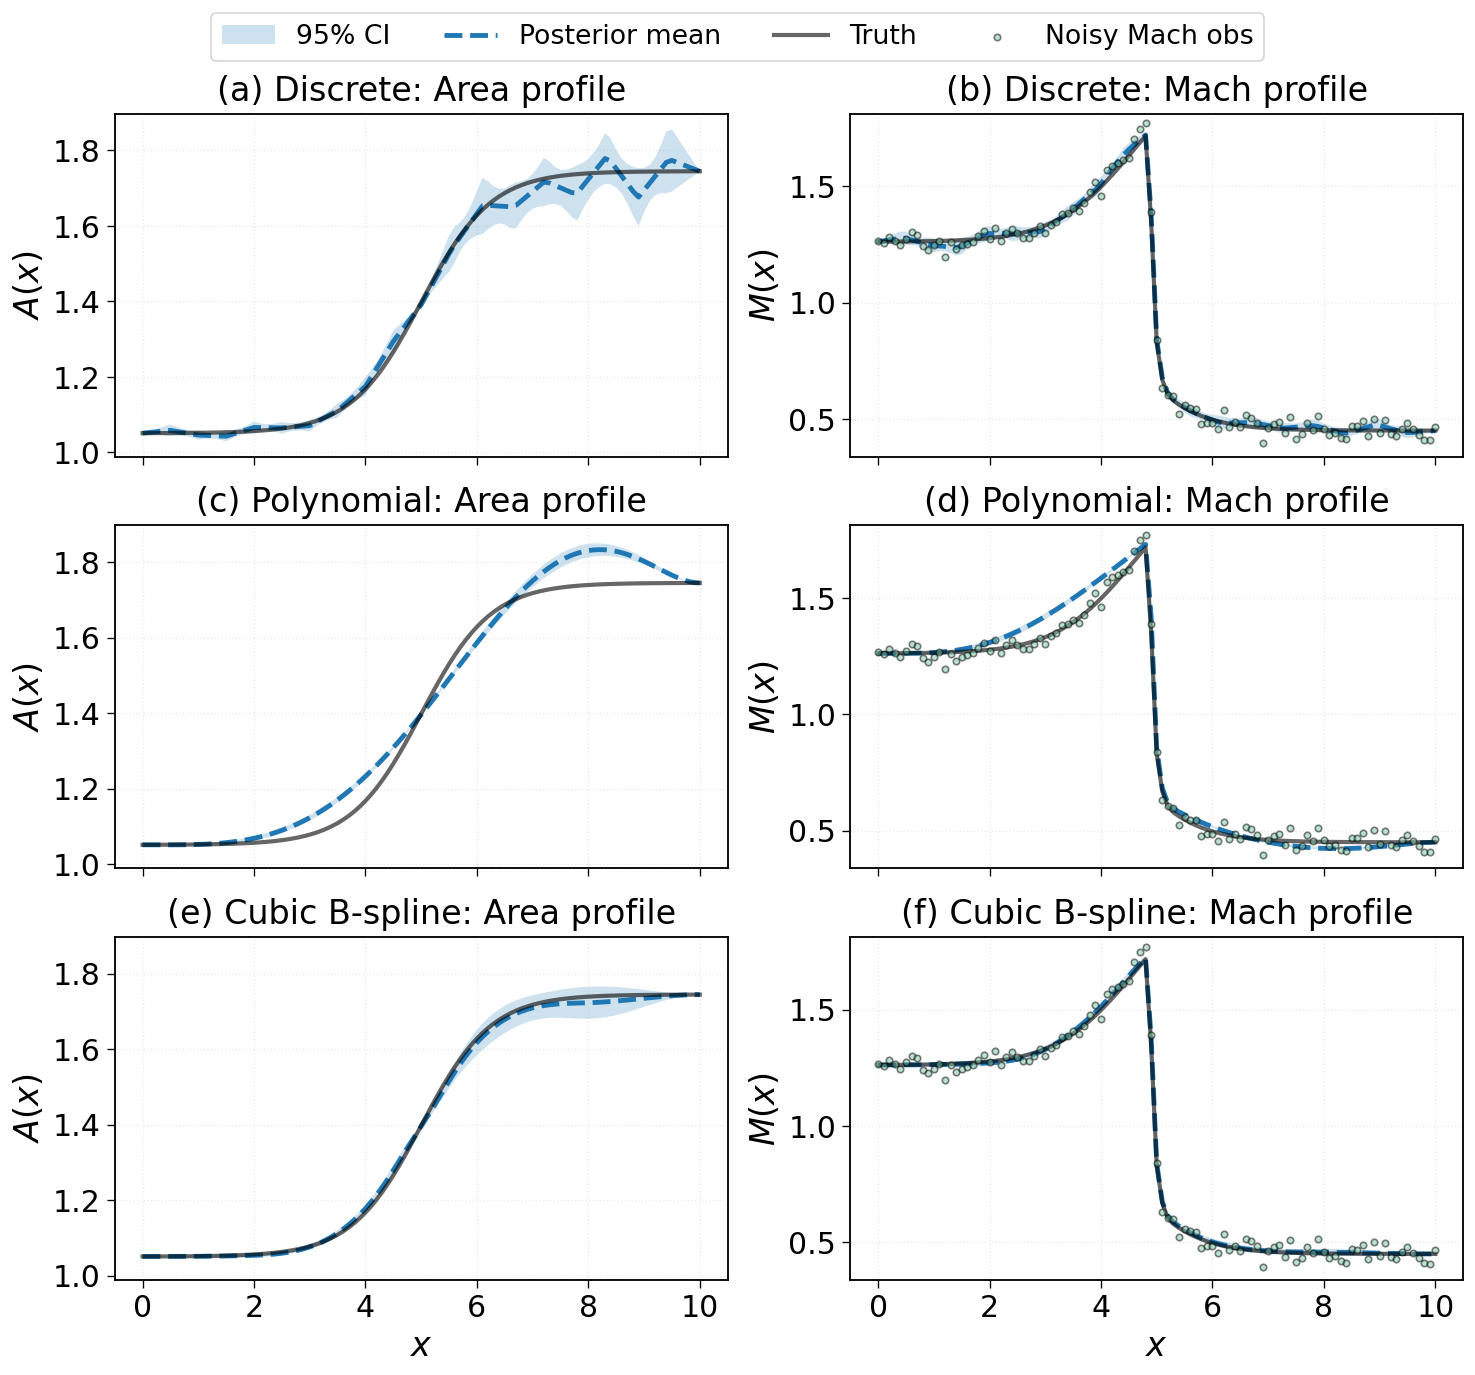

Saved: R3_param_compare_3x2_boxed_defaultfont.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob


plt.rcParams.update({
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "legend.fontsize": 16,
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

def load_npz(path):
    d = np.load(path, allow_pickle=False)
    return {k: d[k] for k in d.files}

def ensure_bands(d, prefix):
    mu = d.get(f"{prefix}_mu", None)
    sd = d.get(f"{prefix}_sd", None)
    lo = d.get(f"{prefix}_lo", None)
    hi = d.get(f"{prefix}_hi", None)
    if (lo is None) or (hi is None):
        if (mu is None) or (sd is None):
            raise KeyError(f"Need either {prefix}_lo/{prefix}_hi OR {prefix}_mu/{prefix}_sd in npz.")
        d[f"{prefix}_lo"] = mu - 2.0 * sd
        d[f"{prefix}_hi"] = mu + 2.0 * sd

def plot_band(ax, x, truth, mu, lo, hi, obs=None, title="", ylabel=""):
    ax.fill_between(x, lo, hi, alpha=0.22, label="95% CI", zorder=1)
    ax.plot(x, mu,linestyle ="--", lw=2.9, label="Posterior mean", zorder=3)
    ax.plot(x, truth, "k", lw=2.5, alpha = 0.6, label="Truth", zorder=4)
    if obs is not None:
        ax.scatter(x, obs, s=15, facecolor='#7BC8A4', edgecolors="black", alpha=0.5, label="Noisy Mach obs", zorder=5)
    ax.set_title(title, pad=8)
    ax.set_ylabel(ylabel)
    ax.grid(True)

    # full box visible
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_visible(True)

def padded_limits(arr_list, pad_frac=0.05):
    a = np.concatenate([np.ravel(np.asarray(v, dtype=np.float64)) for v in arr_list])
    lo, hi = np.min(a), np.max(a)
    pad = pad_frac * (hi - lo + 1e-12)
    return lo - pad, hi + pad

# -----------------------------
# Load latest results
# -----------------------------
paths = {
    "Discrete":   "inverse_nozzle_discrete.npz",
    "Polynomial": "inverse_nozzle_polynomial.npz",
    "Cubic B-spline":   "inverse_nozzle_bspline.npz",
}
print("Using files:")
for k, v in paths.items():
    print(" ", k, "->", v)

D = {name: load_npz(p) for name, p in paths.items()}
for name, d in D.items():
    ensure_bands(d, "A")
    ensure_bands(d, "M")

order = ["Discrete", "Polynomial", "Cubic B-spline"]


A_all, M_all = [], []
for name in order:
    d = D[name]
    A_all += [d["A_true"], d["A_mu"], d["A_lo"], d["A_hi"]]
    M_all += [d["M_true"], d["M_mu"], d["M_lo"], d["M_hi"]]

A_ylim = padded_limits(A_all, 0.05)
M_ylim = padded_limits(M_all, 0.06)


# Figure: 3 × 2 (A and M)

fig, axes = plt.subplots(
    3, 2, figsize=(14.5, 12.0), sharex=True,
    gridspec_kw={"wspace": 0.2, "hspace": 0.2}
)

letters = list("abcdef")
k = 0

for i, name in enumerate(order):
    d = D[name]
    x = d["x"].astype(np.float64)

    # A(x)
    plot_band(
        axes[i, 0], x,
        truth=d["A_true"], mu=d["A_mu"], lo=d["A_lo"], hi=d["A_hi"],
        title=f"({letters[k]}) {name}: Area profile",
        ylabel="$A(x)$"
    )
    axes[i, 0].set_ylim(*A_ylim)
    k += 1

    # M(x)
    plot_band(
        axes[i, 1], x,
        truth=d["M_true"], mu=d["M_mu"], lo=d["M_lo"], hi=d["M_hi"],
        obs=d.get("M_obs", None),
        title=f"({letters[k]}) {name}: Mach profile",
        ylabel="$M(x)$"
    )
    axes[i, 1].set_ylim(*M_ylim)
    k += 1

axes[-1, 0].set_xlabel("$x$")
axes[-1, 1].set_xlabel("$x$")


handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, frameon=True)
fig.subplots_adjust(top=0.92)

# out_png = "R3_param_compare_3x2_boxed_defaultfont.png"
# plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("Saved:", out_png)


Using files:
  Discrete  : ./inverse_nozzle_discrete.npz
  Polynomial: ./inverse_nozzle_polynomial.npz
  Cubic B-spline: ./inverse_nozzle_bspline.npz


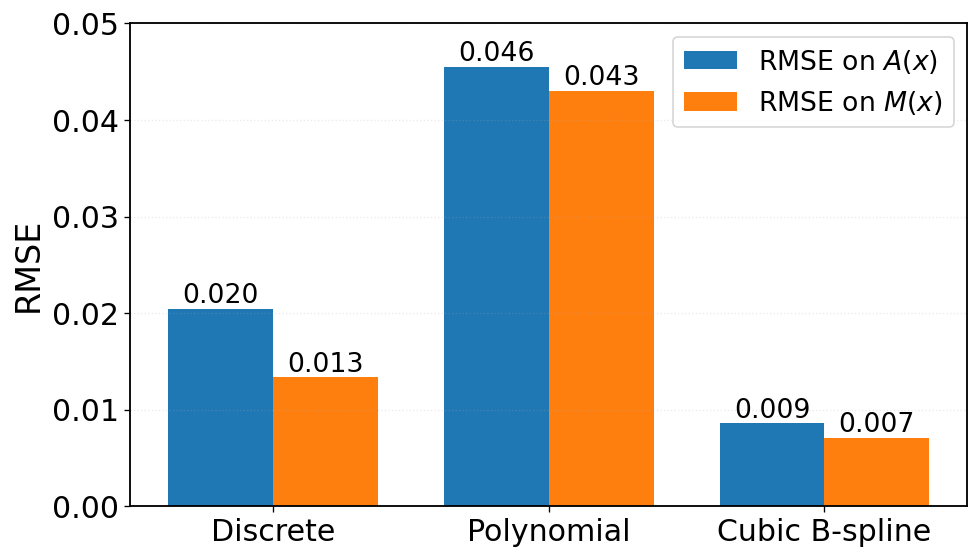

Saved: R3_param_compare_RMSE_bars.png


In [10]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plot style 
# -----------------------------
plt.rcParams.update({
    "font.size": 18,         
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,    
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.1,
})

# -----------------------------
# Load saved npz files
# -----------------------------
DATA_DIR = "."

patterns = {
    "Discrete":   "inverse_nozzle_discrete.npz",
    "Polynomial": "inverse_nozzle_polynomial.npz",
    "Cubic B-spline":   "inverse_nozzle_bspline.npz",
}

def latest_file(pattern, folder="."):
    paths = glob.glob(os.path.join(folder, pattern))
    if not paths:
        raise FileNotFoundError(f"No files match: {os.path.join(folder, pattern)}")
    paths.sort(key=os.path.getmtime)
    return paths[-1]

def load_npz(path):
    d = np.load(path, allow_pickle=False)
    return {k: d[k] for k in d.files}

files = {name: latest_file(pat, DATA_DIR) for name, pat in patterns.items()}
print("Using files:")
for k, v in files.items():
    print(f"  {k:10s}: {v}")

D = {name: load_npz(path) for name, path in files.items()}

def get_ci(d, key_prefix):
    mu_key = f"{key_prefix}_mu"
    lo_key = f"{key_prefix}_lo"
    hi_key = f"{key_prefix}_hi"

    if (mu_key in d) and (lo_key in d) and (hi_key in d):
        return d[mu_key], d[lo_key], d[hi_key]

    cand_keys = [f"{key_prefix}_full_samps", f"{key_prefix}_samps"]
    for ck in cand_keys:
        if ck in d:
            samps = d[ck]
            lo = np.quantile(samps, 0.025, axis=0)
            hi = np.quantile(samps, 0.975, axis=0)
            mu = np.mean(samps, axis=0) if mu_key not in d else d[mu_key]
            return mu, lo, hi

    raise KeyError(f"Missing CI info for '{key_prefix}'.")

# -----------------------------
# Grouped RMSE bars
# -----------------------------
order = ["Discrete", "Polynomial", "Cubic B-spline"]
names = [n for n in order if n in D]

rmseA, rmseM = [], []
for name in names:
    d = D[name]
    A_mu, _, _ = get_ci(d, "A")
    M_mu, _, _ = get_ci(d, "M")
    rmseA.append(np.sqrt(np.mean((A_mu - d["A_true"])**2)))
    rmseM.append(np.sqrt(np.mean((M_mu - d["M_true"])**2)))

x = np.arange(len(names))
w = 0.38

plt.figure(figsize=(8.5, 5.0))
plt.bar(x - w/2, rmseA, width=w, label=r"RMSE on $A(x)$")
plt.bar(x + w/2, rmseM, width=w, label=r"RMSE on $M(x)$")

plt.xticks(x, names)
plt.ylabel("RMSE")
plt.grid(axis="y")

# FORCE y-axis range
plt.ylim(0.0, 0.05)

# numeric labels on bars (bigger font)
for xi, a, m in zip(x, rmseA, rmseM):
    plt.text(xi - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=16)
    plt.text(xi + w/2, m, f"{m:.3f}", ha="center", va="bottom", fontsize=16)

plt.legend(frameon=True)
plt.tight_layout()

out_png = "R3_param_compare_RMSE_bars.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("Saved:", out_png)
